<div class="alert alert-info" style="background-color:#001b79; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>CROSS VAL SCORE  ADA BOOSTER  FOR CLASSIFIER </h2>
</div>

<div class="alert alert-info" style="background-color:#001b32; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Problem  Statement </h2>
</div>

## Module 14 Case study 1 - Cross val and Boosting


### Case Study

### Questions:
- 1.The data file contains numerical attributes that describe a letter and its corresponding class. 
    - Read the datafile “letterCG.data” and set all the numerical attributes as features.
    - Split the data in to train and test sets.
    
- 2. Fit a sequence of AdaBoostClassifier with varying number of weak learners ranging from 1 to 16,keeping the max_depth as 1. 
    - Plot the accuracy on test set against the number of weak learners.
    - Use decision tree classifier as the base classifier.
    
- 3.Repeat step2 with max_depth set as 2.


##  1. Import all Librariy

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
#Read data
df = pd.read_csv (r'..\Dataset\letterCG.bin'  , sep=" ")

df.head()

,Class,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,C,4,10,5,8,2,5,7,7,10,7,6,13,1,8,4,9
1,C,3,5,4,4,2,4,8,5,7,12,9,11,1,10,2,7
2,G,5,10,6,7,3,8,7,8,8,6,7,9,2,7,5,10
3,C,5,9,6,7,4,3,8,6,7,12,10,13,1,9,3,7
4,G,4,8,5,6,3,6,6,7,6,10,7,12,2,9,4,9


##  2. SPLIT DATA AND APPLY MODEL

In [11]:
# set all the numerical attributes as features.

X = df.iloc[:,1:]
Y = df.loc[:,"Class"]
print(X.head())
print(Y.head())

   x-box  y-box  width  high  onpix  x-bar  y-bar  x2bar  y2bar  xybar  x2ybr  \
0      4     10      5     8      2      5      7      7     10      7      6   
1      3      5      4     4      2      4      8      5      7     12      9   
2      5     10      6     7      3      8      7      8      8      6      7   
3      5      9      6     7      4      3      8      6      7     12     10   
4      4      8      5     6      3      6      6      7      6     10      7   

   xy2br  x-ege  xegvy  y-ege  yegvx  
0     13      1      8      4      9  
1     11      1     10      2      7  
2      9      2      7      5     10  
3     13      1      9      3      7  
4     12      2      9      4      9  
0    C
1    C
2    G
3    C
4    G
Name: Class, dtype: object


In [12]:
# Split the data in to train and test sets.
from sklearn.model_selection import train_test_split
train_X, test_X, train_Y, test_Y = train_test_split(X,Y, test_size=.30, random_state=5)
train_X.head()

,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
965,3,7,4,5,2,8,7,8,7,6,6,9,2,7,5,11
1320,3,2,4,4,3,6,7,6,6,7,6,10,3,7,4,9
1475,6,9,8,6,7,7,8,5,3,6,6,9,5,7,7,7
312,2,4,3,3,1,4,9,5,7,11,9,12,1,9,2,7
295,2,1,2,2,1,8,6,6,6,6,5,10,1,7,5,10


In [13]:
print(train_X.shape)
print(train_Y.shape)
print(test_X.shape)
print(test_Y.shape)

(1056, 16)
(1056,)
(453, 16)
(453,)


### 2.1 Fit a sequence of AdaBoostClassifier with varying number of weak learners ranging from 1 to 16,keeping the max_depth as 1. 
- Plot the accuracy on test set against the number of weak learners.
- Use decision tree classifier as the base classifier.

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Used decision tree classifier as the base classifier. max_depth as 1.
base_mdl = DecisionTreeClassifier(max_depth=1) 


In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
accr_list = []
weak_learn = []
accr_list_dct = {}
for i in range(1,17):
    clf = AdaBoostClassifier(n_estimators = i, base_estimator=base_mdl, learning_rate = 1)
    clf.fit(train_X,train_Y)
    estimated_y = clf.predict(test_X)
    # Call evaluate func passing test dataset
    accr  = accuracy_score(test_Y, estimated_y)
    #print(accr)
    #accr_list.append(accr)
    #weak_learn.append(i)
    accr_list_dct[i] = accr
#print(accr_list)
#print(weak_learn)
print(accr_list_dct)

{1: 0.7770419426048565, 2: 0.7924944812362031, 3: 0.7924944812362031, 4: 0.8520971302428256, 5: 0.8631346578366446, 6: 0.8631346578366446, 7: 0.8675496688741722, 8: 0.8675496688741722, 9: 0.891832229580574, 10: 0.8940397350993378, 11: 0.9028697571743929, 12: 0.9161147902869757, 13: 0.9227373068432672, 14: 0.9205298013245033, 15: 0.9161147902869757, 16: 0.9161147902869757}


### 2.2 Plot the accuracy on test set against the number of weak learners

Text(0, 0.5, 'Accuracyr')

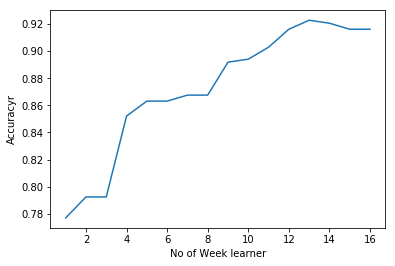

In [16]:
#plt.plot(weak_learn,accr_list)

plt.plot(accr_list_dct.keys(),accr_list_dct.values())
plt.xlabel("No of Week learner")
plt.ylabel("Accuracyr")

### 2.3 Conclusion:

- By graph we can see, week learner =13 has good accuracy (0.92273) compared to all other

## 3. Repeat step2 with max_depth set as 2.

In [17]:
# Used decision tree classifier as the base classifier. max_depth as 2.
base_mdl = DecisionTreeClassifier(max_depth=2) 

accr_list_dct1 = {}
for i in range(1,17):
    clf = AdaBoostClassifier(n_estimators = i, base_estimator=base_mdl, learning_rate = 1)
    clf.fit(train_X,train_Y)
    estimated_y = clf.predict(test_X)
    # Call evaluate func passing test dataset
    accr  = accuracy_score(test_Y, estimated_y)
    accr_list_dct1[i] = accr

print(accr_list_dct1)

{1: 0.8543046357615894, 2: 0.9205298013245033, 3: 0.9028697571743929, 4: 0.9094922737306843, 5: 0.9426048565121413, 6: 0.9448123620309051, 7: 0.9536423841059603, 8: 0.9470198675496688, 9: 0.9492273730684326, 10: 0.9448123620309051, 11: 0.9514348785871964, 12: 0.9602649006622517, 13: 0.9580573951434879, 14: 0.9602649006622517, 15: 0.9624724061810155, 16: 0.9558498896247241}


### 3.1 Plot the accuracy on test set against the number of weak learners

Text(0, 0.5, 'Accuracyr')

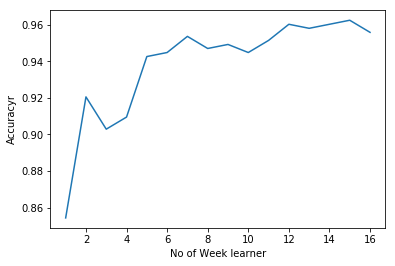

In [18]:
plt.plot(accr_list_dct1.keys(),accr_list_dct1.values())
plt.xlabel("No of Week learner")
plt.ylabel("Accuracyr")

## 4. Conclusion:
By graph we can see, week learner =15 has good accuracy (0.9624) compared to all other